# Trabalho Final Pratico - Python

## Tema 1: Desempenho Academico de Estudantes

Base utilizada: `student-por.csv`, com dados de desempenho na materia de Portugues.

Essa base tem **649 registros** e **33 colunas**, por isso atende aos requisitos minimos do trabalho. A nota final analisada e `G3`, em uma escala de 0 a 20.

O objetivo e verificar como tempo de estudo, reprovacoes anteriores, apoio familiar, escola, sexo, consumo de alcool, faltas e escolaridade dos pais aparecem relacionados ao desempenho final.

## Configuracao do ambiente

Nesta etapa ficam as importacoes e as configuracoes basicas de exibicao. O notebook usa Pandas e NumPy para tratar os dados, Matplotlib e Seaborn para os graficos e `Path` para localizar o CSV na pasta do projeto.

In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11


## 1. Carregamento dos dados

A base `student-por.csv` usa ponto e virgula como separador. Por isso, a leitura correta precisa informar `sep=';'`.

In [11]:
BASE_DIR = Path.cwd()
ARQUIVO_DADOS = BASE_DIR / 'student-por.csv'

df_raw = pd.read_csv(ARQUIVO_DADOS, sep=';', encoding='utf-8')

print('Arquivo usado:', ARQUIVO_DADOS.name)
print('Dimensoes da base:', df_raw.shape)
display(df_raw.head())

Arquivo usado: student-por.csv
Dimensoes da base: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13


A base de Portugues atende aos requisitos minimos do trabalho: possui **649 registros**, **33 colunas**, mais de 4 variaveis numericas e mais de 3 variaveis categoricas.


## 2. Compreensao inicial da base

Antes da analise, verifico o tamanho da base, os tipos das colunas, as estatisticas iniciais e a quantidade de categorias nas variaveis de texto.

In [12]:
print('Dimensoes:', df_raw.shape)
print()
print('-  Informacoes gerais:')
df_raw.info()

print()
print('-  Estatisticas das variaveis numericas:')
display(df_raw.describe().T)

print()
print('-- Cardinalidade das variaveis categoricas:')
cardinalidade = df_raw.select_dtypes(include=['object', 'string']).nunique().sort_values(ascending=False)
display(cardinalidade.to_frame('-  quantidade_de_categorias'))


Dimensoes: (649, 33)

-  Informacoes gerais:
<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20

,count,mean,std,min,25%,50%,75%,max
age,649.00,16.74,1.22,15.00,16.00,17.00,18.00,22.00
Medu,649.00,2.51,1.13,0.00,2.00,2.00,4.00,4.00
Fedu,649.00,2.31,1.10,0.00,1.00,2.00,3.00,4.00
traveltime,649.00,1.57,0.75,1.00,1.00,1.00,2.00,4.00
studytime,649.00,1.93,0.83,1.00,1.00,2.00,2.00,4.00
failures,649.00,0.22,0.59,0.00,0.00,0.00,0.00,3.00
famrel,649.00,3.93,0.96,1.00,4.00,4.00,5.00,5.00
freetime,649.00,3.18,1.05,1.00,3.00,3.00,4.00,5.00
goout,649.00,3.18,1.18,1.00,2.00,3.00,4.00,5.00
Dalc,649.00,1.50,0.92,1.00,1.00,1.00,2.00,5.00



-- Cardinalidade das variaveis categoricas:


,- quantidade_de_categorias
Fjob,5
Mjob,5
reason,4
guardian,3
school,2
Pstatus,2
famsize,2
address,2
sex,2
schoolsup,2


A nota final `G3` varia de 0 a 20. Na base original, a media de `G3` e **11.91**, a mediana e **12.00** e o desvio padrao e **3.23**, indicando uma distribuicao concentrada perto da faixa de aprovacao.


## 3. Dicionario de dados

A tabela abaixo resume as variaveis mais importantes para responder as perguntas do Tema 1.


In [13]:
dicionario = pd.DataFrame([
    ['school', 'Escola do estudante: GP ou MS', 'Categorica', 'Comparar desempenho por escola'],
    ['sex', 'Sexo do estudante: F ou M', 'Categorica', 'Comparar desempenho por sexo'],
    ['age', 'Idade do estudante', 'Numerica discreta', 'Criar faixas etarias'],
    ['Medu', 'Escolaridade da mae, de 0 a 4', 'Numerica ordinal', 'Contexto familiar'],
    ['Fedu', 'Escolaridade do pai, de 0 a 4', 'Numerica ordinal', 'Contexto familiar'],
    ['studytime', 'Tempo semanal de estudo, de 1 a 4', 'Numerica ordinal', 'Pergunta 1'],
    ['failures', 'Numero de reprovacoes anteriores', 'Numerica discreta', 'Pergunta 2 e risco academico'],
    ['famsup', 'Apoio educacional da familia', 'Categorica', 'Pergunta 3'],
    ['Dalc', 'Consumo de alcool em dias uteis, de 1 a 5', 'Numerica ordinal', 'Pergunta 5'],
    ['Walc', 'Consumo de alcool no fim de semana, de 1 a 5', 'Numerica ordinal', 'Pergunta 5'],
    ['absences', 'Numero de faltas', 'Numerica discreta', 'Risco academico e outliers'],
    ['G1', 'Nota do primeiro periodo', 'Numerica', 'Historico de desempenho'],
    ['G2', 'Nota do segundo periodo', 'Numerica', 'Historico de desempenho'],
    ['G3', 'Nota final', 'Numerica', 'Variavel-alvo da analise'],
], columns=['Coluna', 'Descricao', 'Tipo', 'Papel na analise'])

display(dicionario)


,Coluna,Descricao,Tipo,Papel na analise
0,school,Escola do estudante: GP ou MS,Categorica,Comparar desempenho por escola
1,sex,Sexo do estudante: F ou M,Categorica,Comparar desempenho por sexo
2,age,Idade do estudante,Numerica discreta,Criar faixas etarias
3,Medu,"Escolaridade da mae, de 0 a 4",Numerica ordinal,Contexto familiar
4,Fedu,"Escolaridade do pai, de 0 a 4",Numerica ordinal,Contexto familiar
5,studytime,"Tempo semanal de estudo, de 1 a 4",Numerica ordinal,Pergunta 1
6,failures,Numero de reprovacoes anteriores,Numerica discreta,Pergunta 2 e risco academico
7,famsup,Apoio educacional da familia,Categorica,Pergunta 3
8,Dalc,"Consumo de alcool em dias uteis, de 1 a 5",Numerica ordinal,Pergunta 5
9,Walc,"Consumo de alcool no fim de semana, de 1 a 5",Numerica ordinal,Pergunta 5


## 4. Limpeza e tratamento

Nesta parte verifico nulos, duplicados e textos com possiveis inconsistencias. A base ja vem bem organizada, mas a limpeza fica registrada para mostrar o procedimento usado.

In [14]:
df_limpo = df_raw.copy()

nulos_por_coluna = df_limpo.isna().sum().sort_values(ascending=False)
print('Total de valores ausentes:', int(nulos_por_coluna.sum()))
display(nulos_por_coluna[nulos_por_coluna > 0].to_frame('nulos'))

duplicados_antes = df_limpo.duplicated().sum()
print('Duplicados antes da limpeza:', int(duplicados_antes))

df_limpo = df_limpo.drop_duplicates()

df_limpo = df_limpo.dropna(how='all')

colunas_texto = df_limpo.select_dtypes(include=['object', 'string']).columns
df_limpo[colunas_texto] = df_limpo[colunas_texto].apply(lambda coluna: coluna.str.strip().str.lower())
df_limpo['school'] = df_limpo['school'].str.upper()
df_limpo['sex'] = df_limpo['sex'].str.upper()

colunas_numericas = df_limpo.select_dtypes(include='number').columns
colunas_texto = df_limpo.select_dtypes(include=['object', 'string']).columns
df_limpo[colunas_numericas] = df_limpo[colunas_numericas].fillna(df_limpo[colunas_numericas].median())
df_limpo[colunas_texto] = df_limpo[colunas_texto].fillna('nao_informado')

df_limpo['data_processamento'] = pd.to_datetime('2026-06')
df_limpo['ano_processamento'] = df_limpo['data_processamento'].dt.year

print('Dimensoes apos limpeza:', df_limpo.shape)
display(df_limpo.head())


Total de valores ausentes: 0


,nulos


Duplicados antes da limpeza: 0
Dimensoes apos limpeza: (649, 35)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,data_processamento,ano_processamento
0,GP,F,18,u,gt3,a,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11,2026-06-01,2026
1,GP,F,17,u,gt3,t,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11,2026-06-01,2026
2,GP,F,15,u,le3,t,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12,2026-06-01,2026
3,GP,F,15,u,gt3,t,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14,2026-06-01,2026
4,GP,F,16,u,gt3,t,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13,2026-06-01,2026


A base nao apresentou valores ausentes (**0 nulos**) nem registros duplicados (**0 duplicados**). Tambem criei `data_processamento` apenas para demonstrar `pd.to_datetime()`, porque a base nao possui uma coluna de data real.

## 5. Transformacao e criacao de indicadores derivados

Aqui crio colunas que ajudam nas perguntas da analise: situacao de aprovacao, reprovacao anterior, consumo medio de alcool, media parcial, faixas de faltas, faixa etaria, escolaridade media dos pais e risco academico.

In [15]:
df = df_limpo.copy()

df['aprovado'] = np.where(df['G3'] >= 10, 'Aprovado', 'Reprovado')

df['teve_reprovacao'] = np.where(df['failures'] > 0, 'Sim', 'Nao')

def taxa_aprovacao(coluna):
    return (coluna == 'Aprovado').mean() * 100

df['alcool_total'] = df[['Dalc', 'Walc']].mean(axis=1)

df['media_parcial'] = df[['G1', 'G2']].mean(axis=1)

df['faixa_faltas'] = pd.cut(
    df['absences'],
    bins=[-1, 0, 5, 15, df['absences'].max()],
    labels=['Sem faltas', '1 a 5', '6 a 15', 'Mais de 15']
)

df['faixa_etaria'] = pd.cut(
    df['age'],
    bins=[14, 16, 18, 22],
    labels=['15-16', '17-18', '19+']
)

df['educ_pais_media'] = df[['Medu', 'Fedu']].mean(axis=1)
df['nivel_educ_pais'] = pd.cut(
    df['educ_pais_media'],
    bins=[-0.1, 1.49, 2.49, 4],
    labels=['Baixa', 'Media', 'Alta']
)

df['quartil_media_parcial'] = pd.qcut(df['media_parcial'], q=4, duplicates='drop')


df['perfil_estudo'] = np.select(
    [df['studytime'] <= 1, df['studytime'].eq(2), df['studytime'] >= 3],
    ['Baixo', 'Intermediario', 'Alto'],
    default='Nao classificado'
)

def calcular_risco(linha):
    pontos = 0
    if linha['media_parcial'] < 10:
        pontos += 3
    if linha['failures'] > 0:
        pontos += 2
    if linha['absences'] > 10:
        pontos += 1
    if linha['studytime'] <= 1:
        pontos += 1
    if linha['alcool_total'] >= 3:
        pontos += 1
    return pontos

df['score_risco'] = df.apply(lambda linha: calcular_risco(linha), axis=1)

df['risco_academico'] = pd.cut(
    df['score_risco'],
    bins=[-1, 1, 3, 8],
    labels=['Baixo', 'Medio', 'Alto']
)

colunas_mostrar = [
    'G1', 'G2', 'G3', 'media_parcial', 'aprovado', 'failures',
    'teve_reprovacao', 'absences', 'faixa_faltas', 'alcool_total',
    'score_risco', 'risco_academico'
]

display(df[colunas_mostrar].head(10))

,G1,G2,G3,media_parcial,aprovado,failures,teve_reprovacao,absences,faixa_faltas,alcool_total,score_risco,risco_academico
0,0,11,11,5.50,Aprovado,0,Nao,4,1 a 5,1.00,3,Medio
1,9,11,11,10.00,Aprovado,0,Nao,2,1 a 5,1.00,0,Baixo
2,12,13,12,12.50,Aprovado,0,Nao,6,6 a 15,2.50,0,Baixo
3,14,14,14,14.00,Aprovado,0,Nao,0,Sem faltas,1.00,0,Baixo
4,11,13,13,12.00,Aprovado,0,Nao,0,Sem faltas,1.50,0,Baixo
5,12,12,13,12.00,Aprovado,0,Nao,6,6 a 15,1.50,0,Baixo
6,13,12,13,12.50,Aprovado,0,Nao,0,Sem faltas,1.00,0,Baixo
7,10,13,13,11.50,Aprovado,0,Nao,2,1 a 5,1.00,0,Baixo
8,15,16,17,15.50,Aprovado,0,Nao,0,Sem faltas,1.00,0,Baixo
9,12,12,13,12.00,Aprovado,0,Nao,0,Sem faltas,1.00,0,Baixo


O `score_risco` junta sinais simples: notas parciais baixas, reprovacoes anteriores, muitas faltas, pouco tempo de estudo e consumo medio de alcool mais alto. Ele nao prova causa e efeito; serve apenas para organizar perfis de maior atencao.

## 6. Outliers com metodo IQR

Apliquei o metodo IQR em duas variaveis numericas: `absences` e `G3`. A ideia nao e remover automaticamente os valores extremos, mas entender quantos sao e o que eles podem representar.

In [16]:
def resumo_iqr(dataframe, coluna):
    q1 = dataframe[coluna].quantile(0.25)
    q3 = dataframe[coluna].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    mascara_outlier = (dataframe[coluna] < limite_inferior) | (dataframe[coluna] > limite_superior)
    return {
        'coluna': coluna,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'qtd_outliers': int(mascara_outlier.sum()),
        'pct_outliers': mascara_outlier.mean() * 100
    }
outliers = pd.DataFrame([
    resumo_iqr(df, 'absences'),
    resumo_iqr(df, 'G3')
])

display(outliers)


,coluna,q1,q3,iqr,limite_inferior,limite_superior,qtd_outliers,pct_outliers
0,absences,0.00,6.00,6.00,-9.00,15.00,21,3.24
1,G3,10.00,14.00,4.00,4.00,20.00,16,2.47


Pelo IQR, `absences` tem **21 outliers** acima de 15 faltas. Em `G3`, aparecem **16 outliers**, concentrados em notas muito baixas. Como esses valores podem representar situacoes academicas reais, a analise principal mantem os registros e apenas destaca sua influencia.


## 7. Pergunta 1 - Relacao entre tempo de estudo e nota final

Esta pergunta compara o tempo semanal de estudo (`studytime`) com a nota final (`G3`).

In [17]:
analise_estudo = df.groupby('studytime').agg(
    quantidade=('G3', 'size'),
    media_G3=('G3', 'mean'),
    mediana_G3=('G3', 'median'),
    aprovacao_pct=('aprovado', taxa_aprovacao)
).round(2)

display(analise_estudo)


,quantidade,media_G3,mediana_G3,aprovacao_pct
studytime,,,,
1,212,10.84,11.00,76.42
2,305,12.09,12.00,86.56
3,97,13.23,13.00,92.78
4,35,13.06,13.00,94.29


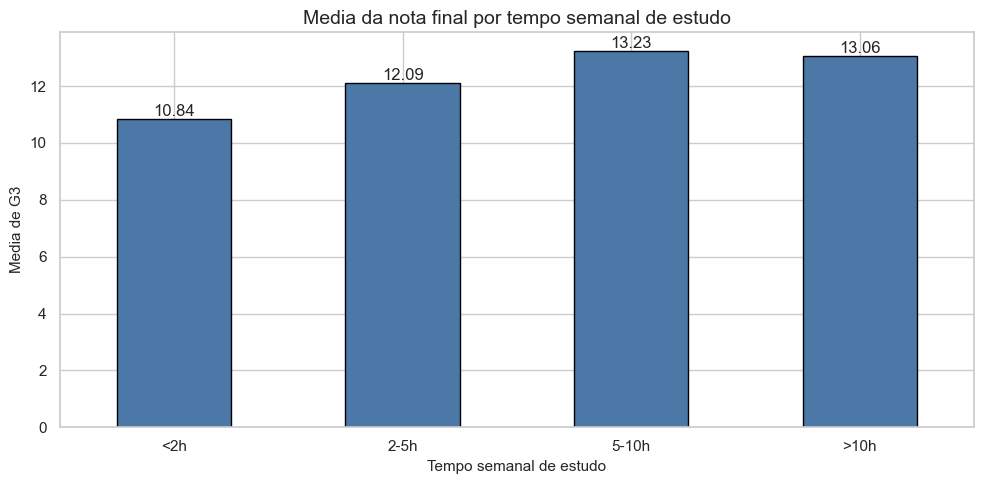

In [18]:
rotulos_estudo = {1: '<2h', 2: '2-5h', 3: '5-10h', 4: '>10h'}
media_estudo = df.groupby('studytime')['G3'].mean().rename(index=rotulos_estudo)

ax = media_estudo.plot(kind='bar', color='#4C78A8', edgecolor='black')
ax.set_title('Media da nota final por tempo semanal de estudo')
ax.set_xlabel('Tempo semanal de estudo')
ax.set_ylabel('Media de G3')
ax.bar_label(ax.containers[0], fmt='%.2f')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Interpretacao:** existe uma tendencia positiva: estudantes no nivel 1 de estudo tiveram media **10.84**, enquanto o nivel 3 chegou a **13.23**. O nivel 4 ficou muito proximo (**13.06**), sugerindo que estudar mais esta associado a melhor desempenho, embora o ganho nao cresca indefinidamente.


## 8. Pergunta 2 - Reprovacoes anteriores e desempenho

Aqui comparamos estudantes com e sem reprovacoes anteriores (`failures > 0`).


In [19]:
analise_reprovacao = df.groupby('teve_reprovacao').agg(
    quantidade=('G3', 'size'),
    media_G3=('G3', 'mean'),
    mediana_G3=('G3', 'median'),
    aprovacao_pct=('aprovado', taxa_aprovacao),
    faltas_medias=('absences', 'mean')
).round(2)

display(analise_reprovacao)


,quantidade,media_G3,mediana_G3,aprovacao_pct,faltas_medias
teve_reprovacao,,,,,
Nao,549,12.51,12.00,90.71,3.35
Sim,100,8.59,10.00,51.00,5.35


**Interpretacao:** estudantes sem reprovacao anterior tiveram media **12.51** em `G3`, contra **8.59** entre os que ja reprovaram. Essa e uma das diferencas mais fortes observadas, o que torna `failures` uma variavel importante para identificar risco academico.


## 9. Pergunta 3 - Apoio familiar e aprovacao

A variavel `famsup` indica se o estudante recebe apoio educacional da familia.


In [20]:
analise_famsup = df.groupby('famsup').agg(
    quantidade=('G3', 'size'),
    media_G3=('G3', 'mean'),
    mediana_G3=('G3', 'median'),
    aprovacao_pct=('aprovado', taxa_aprovacao)
).round(2)

tab_famsup = pd.crosstab(df['famsup'], df['aprovado'], normalize='index').mul(100).round(2)

display(analise_famsup)
display(tab_famsup)


,quantidade,media_G3,mediana_G3,aprovacao_pct
famsup,,,,
no,251,11.67,12.00,82.87
yes,398,12.06,12.00,85.68


aprovado,Aprovado,Reprovado
famsup,,
no,82.87,17.13
yes,85.68,14.32


**Interpretacao:** estudantes com apoio familiar tiveram media **12.06** e aprovacao de **85.68%**. Sem apoio familiar, a media foi **11.67** e a aprovacao **82.87%**. A diferenca existe, mas e moderada.


## 10. Pergunta 4 - Diferencas por escola e sexo

Nesta parte uso um agrupamento por duas colunas (`school` e `sex`) para comparar media, mediana, desvio padrao, aprovacao e faltas.

In [21]:
analise_escola_sexo = df.groupby(['school', 'sex']).agg(
    quantidade=('G3', 'size'),
    media_G3=('G3', 'mean'),
    mediana_G3=('G3', 'median'),
    desvio_G3=('G3', 'std'),
    aprovacao_pct=('aprovado', taxa_aprovacao),
    faltas_medias=('absences', 'mean')
).round(2)

display(analise_escola_sexo)


quantidade  media_G3  mediana_G3  desvio_G3  aprovacao_pct  \
school sex                                                               
GP     F           237     13.00       13.00       2.34          96.20   
       M           186     12.03       12.00       2.86          87.63   
MS     F           146     11.03       11.00       3.79          71.92   
       M            80      9.95       10.00       3.84          66.25   

            faltas_medias  
school sex                 
GP     F             4.41  
       M             3.97  
MS     F             2.23  
       M             3.32

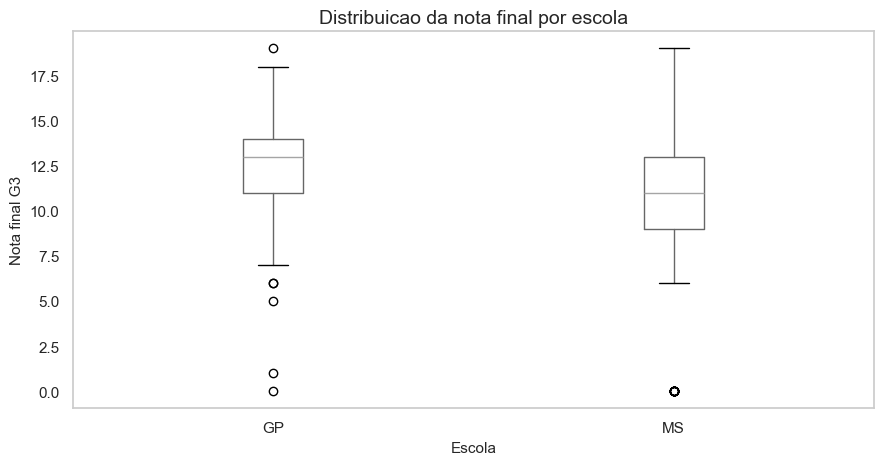

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
df.boxplot(column='G3', by='school', ax=ax, grid=False)
ax.set_title('Distribuicao da nota final por escola')
ax.set_xlabel('Escola')
ax.set_ylabel('Nota final G3')
plt.suptitle('')
plt.tight_layout()
plt.show()


**Interpretacao:** a combinacao com melhor media foi `GP/F`, com **13.00**. A menor media apareceu em `MS/M`, com **9.95**. Isso sugere diferencas relevantes entre escolas e grupos, mas a analise nao permite afirmar que escola ou sexo sejam causas isoladas do desempenho.


## 11. Pergunta 5 - Consumo de alcool e nota final

As colunas `Dalc` e `Walc` indicam consumo de alcool em dias uteis e no fim de semana. Primeiro calculo a correlacao com `G3` e depois observo as medias por nivel de consumo.

In [23]:
correlacao_alcool = df[['Dalc', 'Walc', 'alcool_total', 'G3']].corr()['G3'].drop('G3').sort_values()
analise_alcool = df.groupby('Dalc').agg(
    quantidade=('G3', 'size'),
    media_G3=('G3', 'mean'),
    aprovacao_pct=('aprovado', taxa_aprovacao)
).round(2)

display(correlacao_alcool.to_frame('correlacao_com_G3'))
display(analise_alcool)


,correlacao_com_G3
alcool_total,-0.21
Dalc,-0.20
Walc,-0.18


,quantidade,media_G3,aprovacao_pct
Dalc,,,
1,451,12.30,87.14
2,121,11.36,80.17
3,43,11.14,83.72
4,17,8.94,70.59
5,17,10.24,64.71


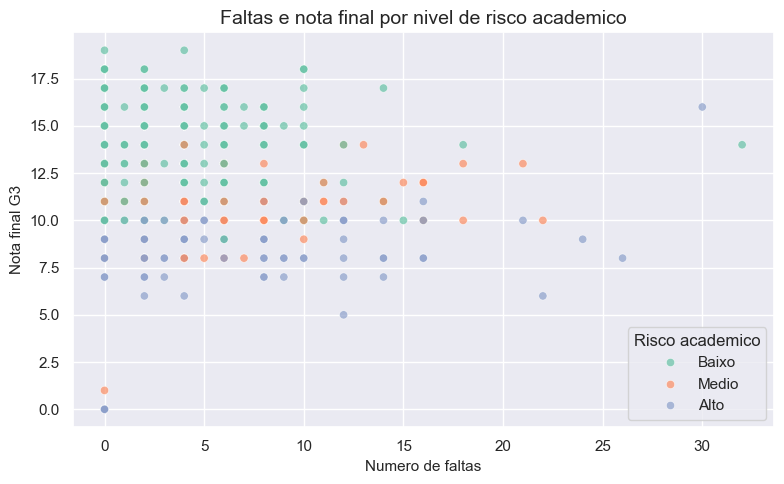

In [53]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='absences', y='G3', hue='risco_academico', alpha=0.7, ax=ax)
ax.set_title('Faltas e nota final por nivel de risco academico')
ax.set_xlabel('Numero de faltas')
ax.set_ylabel('Nota final G3')
ax.legend(title='Risco academico')
plt.tight_layout()
plt.show()


**Interpretacao:** as correlacoes entre alcool e nota final sao negativas, mas fracas: `Dalc` = **-0.205**, `Walc` = **-0.177** e `alcool_total` = **-0.209**. Isso indica associacao negativa, nao causalidade; outros fatores como estudo, historico de notas e reprovacoes parecem mais fortes.


## 12. Pergunta 6 - Indice de risco academico

O indice de risco combina media parcial, reprovacoes, faltas, pouco estudo e consumo medio de alcool. Ele foi criado para separar os estudantes em grupos simples: baixo, medio e alto risco.

In [25]:
analise_risco = df.groupby('risco_academico', observed=True).agg(
    quantidade=('G3', 'size'),
    media_G3=('G3', 'mean'),
    mediana_G3=('G3', 'median'),
    aprovacao_pct=('aprovado', taxa_aprovacao),
    faltas_medias=('absences', 'mean')
).round(2)

display(analise_risco)


,quantidade,media_G3,mediana_G3,aprovacao_pct,faltas_medias
risco_academico,,,,,
Baixo,406,13.47,13.00,99.75,2.82
Medio,104,10.52,11.00,82.69,4.97
Alto,139,8.39,9.00,41.73,5.13


**Interpretacao:** o grupo de risco baixo teve media **13.47** e aprovacao de **99.75%**. Ja o grupo de risco alto teve media **8.39** e aprovacao de **41.73%**. Como o indice usa `G1` e `G2`, a comparacao com `G3` fica mais coerente do que usar diretamente a nota final dentro do proprio indice.


## 13. Pergunta 7 - Correlacoes mais fortes com a nota final

Nesta parte calculo a matriz de correlacao para ver quais variaveis numericas ficam mais associadas a `G3`.

In [26]:
colunas_corr = [
    'age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
    'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
    'absences', 'G1', 'G2', 'G3', 'alcool_total',
    'media_parcial', 'educ_pais_media', 'score_risco'
]

corr = df[colunas_corr].corr()
correlacoes_g3 = corr['G3'].drop('G3').sort_values(key=lambda s: s.abs(), ascending=False)

display(correlacoes_g3.head(10).to_frame('correlacao_com_G3'))


,correlacao_com_G3
G2,0.92
media_parcial,0.90
G1,0.83
score_risco,-0.66
failures,-0.39
studytime,0.25
educ_pais_media,0.25
Medu,0.24
Fedu,0.21
alcool_total,-0.21


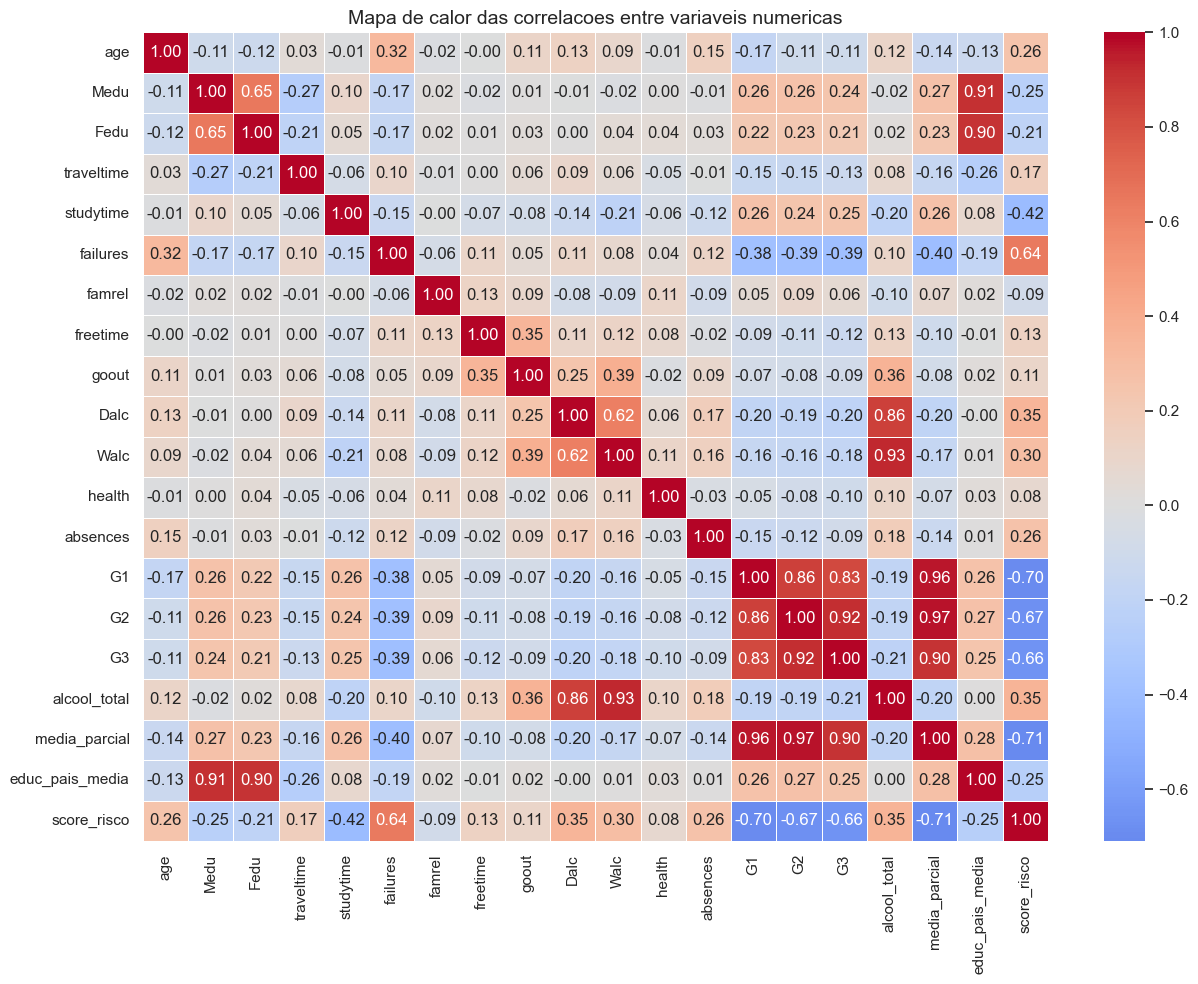

In [27]:
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Mapa de calor das correlacoes entre variaveis numericas')
plt.tight_layout()
plt.show()


**Interpretacao:** as maiores correlacoes com `G3` foram `G2` (**0.919**), `media_parcial` (**0.905**) e `G1` (**0.826**), o que e esperado porque representam notas anteriores. Entre fatores de contexto, `failures` teve correlacao negativa de **-0.393**. Correlacao nao implica causalidade, mas ajuda a priorizar variaveis para investigacao.


## 14. Pergunta 8 - Tabela pivo por escola e escolaridade dos pais

A tabela dinamica compara a media de `G3` por escola e nivel medio de escolaridade dos pais.


In [28]:
pivot_escola_educacao = pd.pivot_table(
    df,
    values='G3',
    index='school',
    columns='nivel_educ_pais',
    aggfunc='mean',
    observed=True
).round(2)

display(pivot_escola_educacao)


nivel_educ_pais,Baixa,Media,Alta
school,,,
GP,11.93,12.01,12.99
MS,9.93,10.48,11.38


**Interpretacao:** na escola `GP`, estudantes com nivel educacional familiar alto tiveram media **12.99**. Na escola `MS`, o grupo com baixa escolaridade familiar teve media **9.93**. A tabela sugere que escola e contexto familiar podem se combinar na explicacao do desempenho.


## 15. Visualizacoes obrigatorias restantes

As proximas celulas completam os graficos exigidos: histograma, linha e barras empilhadas. Os outros tipos ja apareceram nas secoes anteriores.

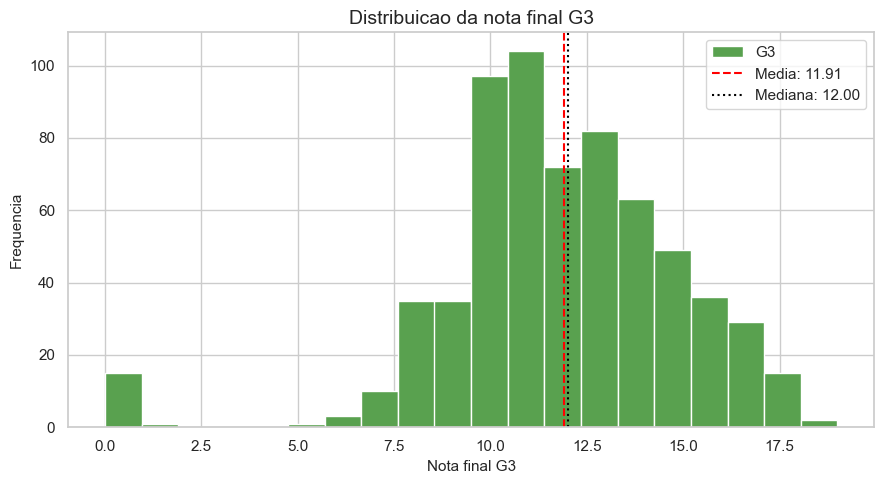

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))
df['G3'].plot(kind='hist', bins=20, edgecolor='white', color='#59A14F', ax=ax)
ax.axvline(df['G3'].mean(), color='red', linestyle='--', label=f"Media: {df['G3'].mean():.2f}")
ax.axvline(df['G3'].median(), color='black', linestyle=':', label=f"Mediana: {df['G3'].median():.2f}")
ax.set_title('Distribuicao da nota final G3')
ax.set_xlabel('Nota final G3')
ax.set_ylabel('Frequencia')
ax.legend()
plt.tight_layout()
plt.show()


**Interpretacao:** a distribuicao de `G3` esta concentrada perto de 10 a 14, com media **11.91** e mediana **12.00**. A assimetria negativa (**-0.91**) indica presenca de algumas notas muito baixas puxando a media para baixo.


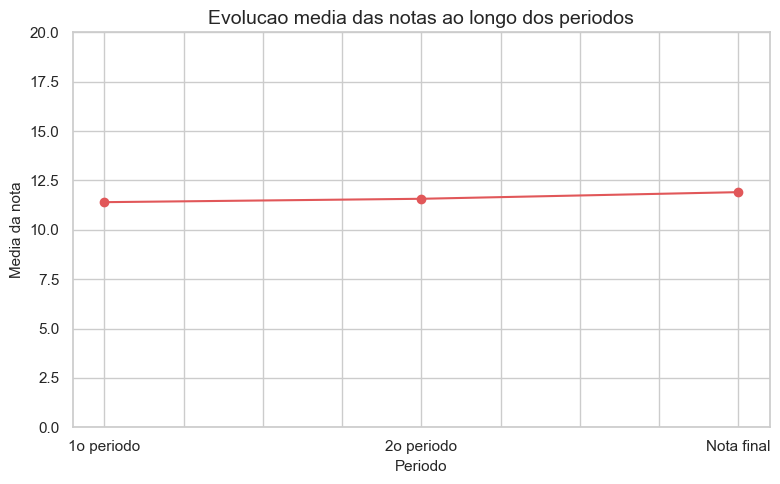

In [30]:
notas_periodos = df[['G1', 'G2', 'G3']].mean().rename(index={
    'G1': '1o periodo',
    'G2': '2o periodo',
    'G3': 'Nota final'
})

fig, ax = plt.subplots(figsize=(8, 5))
notas_periodos.plot(kind='line', marker='o', color='#E15759', ax=ax)
ax.set_title('Evolucao media das notas ao longo dos periodos')
ax.set_xlabel('Periodo')
ax.set_ylabel('Media da nota')
ax.set_ylim(0, 20)
plt.tight_layout()
plt.show()


**Interpretacao:** o grafico de linha nao representa uma serie temporal com datas, e sim a sequencia academica `G1 -> G2 -> G3`. Ele mostra se a media da turma melhora, piora ou se mantem estavel ao longo dos tres periodos avaliados.


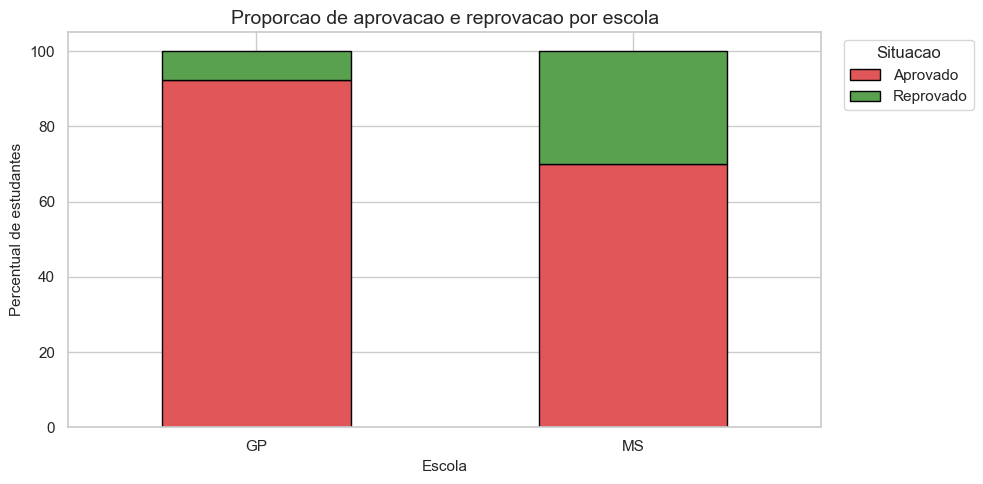

In [34]:
tab_empilhada = pd.crosstab(df['school'], df['aprovado'], normalize='index').mul(100)

ax = tab_empilhada.plot(kind='bar', stacked=True, color=['#E15759', '#59A14F'], edgecolor='black')
ax.set_title('Proporcao de aprovacao e reprovacao por escola')
ax.set_xlabel('Escola')
ax.set_ylabel('Percentual de estudantes')
ax.legend(title='Situacao', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Interpretacao:** as barras empilhadas facilitam comparar a composicao de aprovados e reprovados dentro de cada escola. Esse tipo de grafico e mais adequado que barras simples quando o foco e proporcao entre categorias.


## 16. Interpretacao estatistica: media, mediana, desvio padrao e assimetria

Para cumprir a parte estatistica da rubrica, comparo media, mediana, desvio padrao e assimetria de `G3` e `absences`.

In [35]:
estatisticas_chave = df[['G3', 'absences']].agg(['mean', 'median', 'std', 'skew']).T.round(2)
display(estatisticas_chave)


,mean,median,std,skew
G3,11.91,12.00,3.23,-0.91
absences,3.66,2.00,4.64,2.02


**Interpretacao:** em `G3`, media (**11.91**) e mediana (**12.00**) sao proximas, mas a assimetria de **-0.91** mostra cauda para notas baixas. Em `absences`, a media (**3.66**) e maior que a mediana (**2.00**) e a assimetria e **2.02**, indicando que poucos estudantes com muitas faltas elevam a media.


## 17. Indicadores sinteticos

A tabela abaixo resume 7 indicadores gerais da analise.

In [36]:
indicadores = pd.DataFrame({
    'Indicador': [
        'Media geral de G3',
        'Mediana geral de G3',
        'Desvio padrao de G3',
        '% de aprovacao',
        '% de reprovacao',
        '% com faltas altas (>10)',
        'Melhor perfil de estudo'
    ],
    'Valor': [
        f"{df['G3'].mean():.2f}",
        f"{df['G3'].median():.2f}",
        f"{df['G3'].std():.2f}",
        f"{(df['aprovado'] == 'Aprovado').mean() * 100:.2f}%",
        f"{(df['aprovado'] == 'Reprovado').mean() * 100:.2f}%",
        f"{(df['absences'] > 10).mean() * 100:.2f}%",
        df.groupby('perfil_estudo')['G3'].mean().idxmax()
    ]
})

display(indicadores.set_index('Indicador'))


,Valor
Indicador,
Media geral de G3,11.91
Mediana geral de G3,12.00
Desvio padrao de G3,3.23
% de aprovacao,84.59%
% de reprovacao,15.41%
% com faltas altas (>10),7.55%
Melhor perfil de estudo,Alto


Os indicadores mostram um desempenho geral positivo: media **11.91**, aprovacao de **84.59%** e reprovacao de **15.41%**. Apenas **7.55%** dos estudantes tiveram mais de 10 faltas, e o melhor perfil de estudo foi **Alto**, com media aproximada de **13.18**.


## 18. Conclusoes e limitacoes

O resultado mais forte da analise foi a relacao entre a nota final e as notas anteriores. `G2` teve correlacao de **0.919** com `G3`, `media_parcial` teve correlacao de **0.905** e `G1` teve correlacao de **0.826**. Na pratica, quem ja vinha bem nos dois primeiros periodos tende a terminar melhor.

As reprovacoes anteriores tambem pesaram bastante. Estudantes sem reprovacao tiveram media **12.51** em `G3`, enquanto estudantes com reprovacao anterior tiveram media **8.59**. O tempo de estudo tambem mostrou uma tendencia positiva: a media foi de **10.84** no menor nivel de estudo e chegou a **13.23** no nivel 3.

O apoio familiar apareceu com diferenca menor: a aprovacao foi **85.68%** entre estudantes com apoio e **82.87%** entre estudantes sem apoio. O consumo de alcool teve relacao negativa com a nota final, mas fraca, com correlacao de **-0.209** para o indicador combinado.

O indice de risco academico ajudou a separar os grupos. O grupo de risco alto teve media **8.39** e aprovacao de **41.73%**, bem abaixo do grupo de risco baixo. O indice nao usa `G3`; ele usa `G1`, `G2`, faltas, reprovacoes, estudo e alcool.

**Limitacoes:** os dados mostram associacoes, mas nao provam causalidade. Alem disso, a base representa estudantes portugueses de um contexto especifico. Por isso, os resultados nao devem ser generalizados para todos os estudantes.